# Notebook 4 | hls4ml: From Keras Model to FPGA Bitstream

> **Workshop: From Algorithm to Hardware: Machine Learning in Embedded Systems | April 2026**   

This notebook walks through the full hls4ml workflow: converting a trained Keras model to synthesisable HLS C++, verifying correctness numerically, and understanding the configuration knobs that control hardware behaviour.

## 1. What is hls4ml?

**hls4ml** (High-Level Synthesis for Machine Learning) is an open-source Python library developed at CERN that automates the translation of trained ML models into **HLS C++ code** that can be compiled and deployed on FPGAs.

The key idea: instead of writing RTL (Verilog/VHDL) by hand, you write a normal Keras/PyTorch model, and hls4ml emits the hardware description automatically.


## 2. The hls4ml Workflow


![alt text](hls4ml_workflow.png)

## 3. Build & Train a Reference Model

We use a small MLP on the Iris dataset: simple enough to synthesise quickly, but real enough to show all hls4ml concepts.


![alt text](iris_dataset.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Data 
iris = load_iris()
X, y = iris.data.astype(np.float32), iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Model definition
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    keras.layers.Dense(8,  activation='relu'),
    keras.layers.Dense(3,  activation='softmax'),
], name='iris_mlp')

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

2026-04-19 21:55:11.796914: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 21:55:11.799153: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 21:55:11.842920: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 21:55:11.843595: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-19 21:55:12.571224: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Model: "iris_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80        
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 3)                 27        
                                                                 
Total params: 243
Trainable params: 243
Non-trainable params: 0
_________________________________________________________________


Test accuracy: 0.9667


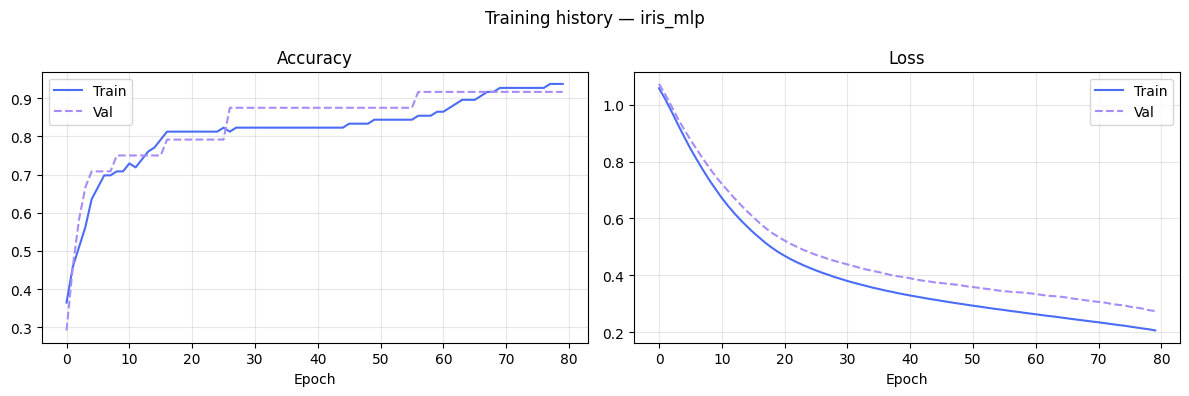

In [2]:
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

# Training curves 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     color='#4B6CF7', label='Train')
axes[0].plot(history.history['val_accuracy'], color='#A78BFA', linestyle='--', label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     color='#4B6CF7', label='Train')
axes[1].plot(history.history['val_loss'], color='#A78BFA', linestyle='--', label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training history — iris_mlp', fontsize=12)
plt.tight_layout()
plt.show()

## 4. hls4ml Configuration

The `HLSConfig` dictionary is the main control surface. The most important knobs:

| Key | What it controls |
|-----|-----------------|
| `Precision` | Default fixed-point type for weights & activations |
| `ReuseFactor` | Global reuse factor (can be overridden per layer) |
| `LayerName Precision` | Per-layer precision override |
| `LayerName ReuseFactor` | Per-layer reuse override |

All precisions use the `ap_fixed<W,I>` notation from Notebook 3.

In [ ]:
# hls4ml config 

hls_config = {
    'Model': {
        'Precision': 'ap_fixed<16,6>',   # default for all layers
        'ReuseFactor': 1,                 # full parallelism
    },
    'LayerName': {
        # First Dense: we can afford 8-bit here (inputs are small)
        'dense': {
            'Precision': {
                'weight':  'ap_fixed<8,3>',
                'bias':    'ap_fixed<8,3>',
                'result':  'ap_fixed<16,6>',
            },
            'ReuseFactor': 1,
        },
        # Second Dense: keep 16-bit for activations
        'dense_1': {
            'ReuseFactor': 2,   # 2x fewer DSPs, 2x latency
        },
        # Output: full precision for stable softmax
        'dense_2': {
            'Precision': {
                'weight': 'ap_fixed<16,6>',
                'result': 'ap_fixed<16,6>',
            },
        },
    },
}

import json as _json
print('hls4ml configuration:')
print(_json.dumps(hls_config, indent=2))

hls4ml configuration:
{
  "Model": {
    "Precision": "ap_fixed<16,6>",
    "ReuseFactor": 1
  },
  "LayerName": {
    "dense": {
      "Precision": {
        "weight": "ap_fixed<8,3>",
        "bias": "ap_fixed<8,3>",
        "result": "ap_fixed<16,6>"
      },
      "ReuseFactor": 1
    },
    "dense_1": {
      "ReuseFactor": 2
    },
    "dense_2": {
      "Precision": {
        "weight": "ap_fixed<16,6>",
        "result": "ap_fixed<16,6>"
      }
    }
  }
}


## 5. Model Conversion

`hls4ml.convert_from_keras_model()` parses each Keras layer and emits the corresponding HLS C++ template. The output is a directory containing:

```
my_project/
├── firmware/
│   ├── myproject.cpp      <- top-level inference function
│   ├── myproject.h
│   ├── parameters.h       <- weights and ap_fixed types
│   ├── nnet_utils/        <- layer-level C++ templates
│   └── weights/           <- weight .h files
├── myproject_test.cpp
├── build_prj.tcl          <- Vivado HLS script
└── vivado_synth.tcl
```

In [5]:
import os

# PATH Vitis HLS installation
os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2024.1/bin:' + os.environ['PATH']
os.environ['PATH']

os.environ["XILINX_AP_INCLUDE"] = "-I/tools/Xilinx/Vitis_HLS/2024.1/include"
print(os.environ["XILINX_AP_INCLUDE"])

-I/tools/Xilinx/Vitis_HLS/2024.1/include


In [ ]:
# Conversion (requires hls4ml + Vivado HLS) 
# Uncomment when running in a properly configured environment.


import hls4ml

PART = 'xc7z020-clg400-1'
SYNTH_DIR = 'hls4ml_iris'
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config    = hls_config,
    output_dir    = SYNTH_DIR,
    backend       = 'Vitis',
    part         = PART,            
)


hls_model.compile()
hls_model.build(csim=False, synth=True)

print('Conversion would produce:')
for f in [
    'hls4ml_iris/firmware/myproject.cpp',
    'hls4ml_iris/firmware/parameters.h',
    'hls4ml_iris/firmware/weights/w1.h',
    'hls4ml_iris/build_prj.tcl',
]:
    print(f'  {f}')

Interpreting Sequential
Topology:
Layer name: dense_input, layer type: InputLayer, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: dense, layer type: Dense, input shapes: [[None, 4]], output shape: [None, 16]
Layer name: dense_1, layer type: Dense, input shapes: [[None, 16]], output shape: [None, 8]
Layer name: dense_2, layer type: Dense, input shapes: [[None, 8]], output shape: [None, 3]
Creating HLS model
Writing HLS project
Done

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Sun Apr 19 22:07:28 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ro' on host 'ro

## 6. Numerical Verification (C-Simulation)

Before spending hours on synthesis, hls4ml's **C-simulation** compiles the HLS code with GCC (no FPGA needed) and runs inference. This lets you catch precision bugs instantly.

The key metric is **bit-match rate**: fraction of test samples where the HLS model and the Keras model agree on the top-1 class.

In [9]:
# C-simulation verification: real HLS inference (no approximation)
import numpy as np

# Run C-sim prediction (compiles HLS C++ with GCC, no FPGA needed)
hls_preds = hls_model.predict(X_test)

keras_preds   = model.predict(X_test, verbose=0)
keras_classes = keras_preds.argmax(axis=1)
hls_classes   = hls_preds.argmax(axis=1)

match_rate = (keras_classes == hls_classes).mean()
print(f'Keras accuracy  : {(keras_classes == y_test).mean():.4f}')
print(f'HLS-sim accuracy: {(hls_classes  == y_test).mean():.4f}')
print(f'Bit-match rate  : {match_rate:.4f}  ({int(match_rate*len(y_test))}/{len(y_test)} samples agree)')

Keras accuracy  : 0.9667
HLS-sim accuracy: 0.9667
Bit-match rate  : 1.0000  (30/30 samples agree)


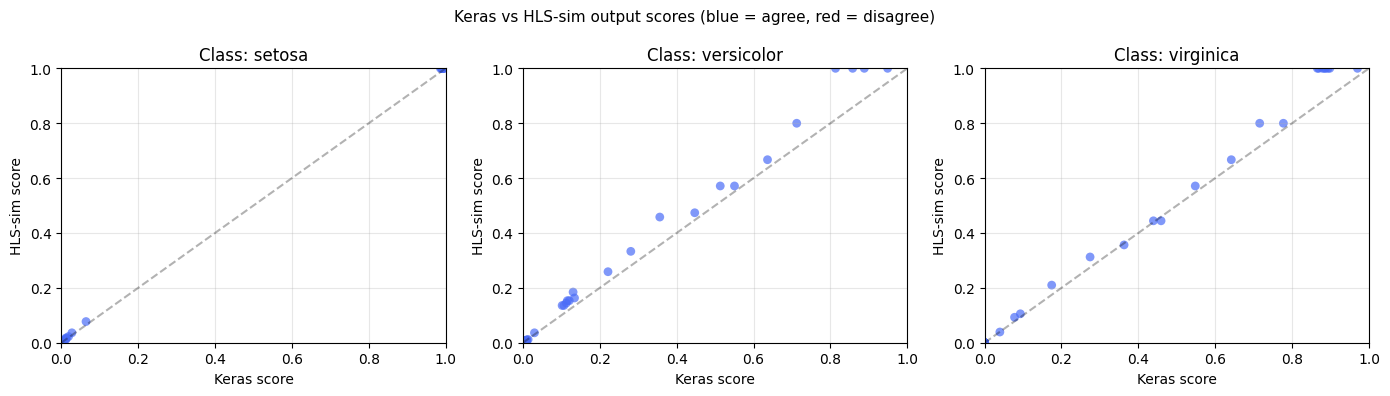

In [10]:
# Score distribution comparison 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names = iris.target_names

for i, ax in enumerate(axes):
    ax.scatter(keras_preds[:, i], hls_preds[:, i],
               c=['#4B6CF7' if k == h else '#EF4444'
                  for k, h in zip(keras_classes, hls_classes)],
               alpha=0.7, s=40, edgecolors='none')
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', alpha=0.3)
    ax.set_xlabel('Keras score')
    ax.set_ylabel('HLS-sim score')
    ax.set_title(f'Class: {class_names[i]}')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.grid(True, alpha=0.3)

plt.suptitle('Keras vs HLS-sim output scores (blue = agree, red = disagree)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Weight Distribution Profiling

hls4ml's profiling tools help you choose the right `ap_fixed<W,I>` for each layer. The idea: inspect the actual distribution of weights and activations, then pick I (integer bits) to cover the range and W to hit the required precision.

dense: |max|=0.737 -> recommend I >= 2
dense_1: |max|=0.777 -> recommend I >= 2
dense_2: |max|=1.070 -> recommend I >= 3


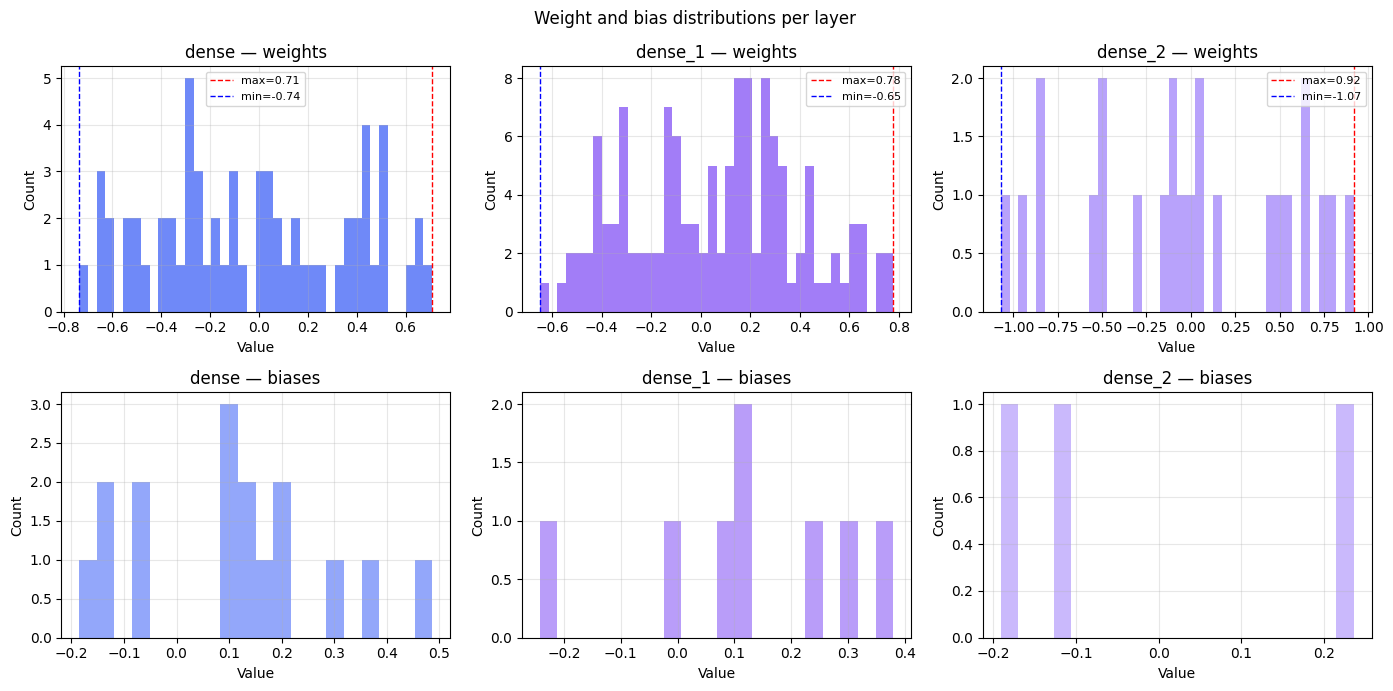

In [11]:
# Weight profiling 
import math

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
colors = ['#4B6CF7', '#8B5CF6', '#A78BFA']

dense_layers = [l for l in model.layers if l.get_weights()]

for col, (layer, color) in enumerate(zip(dense_layers, colors)):
    weights, biases = layer.get_weights()
    w_flat = weights.flatten()
    b_flat = biases.flatten()

    ax = axes[0, col]
    ax.hist(w_flat, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(w_flat.max(), color='red',  linestyle='--', linewidth=1, label=f'max={w_flat.max():.2f}')
    ax.axvline(w_flat.min(), color='blue', linestyle='--', linewidth=1, label=f'min={w_flat.min():.2f}')
    ax.set_title(f'{layer.name} — weights')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.hist(b_flat, bins=20, color=color, alpha=0.6, edgecolor='none')
    ax.set_title(f'{layer.name} — biases')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

    max_abs  = max(abs(w_flat.max()), abs(w_flat.min()))
    I_needed = math.ceil(math.log2(max_abs + 1)) + 1
    print(f'{layer.name}: |max|={max_abs:.3f} -> recommend I >= {I_needed}')

plt.suptitle('Weight and bias distributions per layer', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Precision vs. Accuracy Trade-off

Not all bits are equal. This sweep shows how model accuracy degrades as we reduce the total bit-width W, keeping I fixed.

In [13]:
# Sweep bit-width — real hls4ml C-sim per configuration
import pandas as pd
REUSE_FACTOR = 1

results = []

for W in [4, 6, 8, 10, 12, 16]:
    for I in [2, 3, 4]:
        if I >= W:
            continue

        ap = f'ap_fixed<{W},{I}>'

        # Re-convert with this precision
        cfg = hls4ml.utils.config_from_keras_model(model, granularity='name')
        cfg['Model']['Precision']   = ap
        cfg['Model']['ReuseFactor'] = REUSE_FACTOR

        hls_m = hls4ml.converters.convert_from_keras_model(
            model,
            hls_config = cfg,
            output_dir = f'hls_sweep_W{W}_I{I}',
            backend    = 'Vitis',
            part       = PART
        )
        hls_m.compile()   # GCC C-sim, no FPGA needed

        preds = hls_m.predict(X_test)
        acc   = (preds.argmax(1) == y_test).mean()
        results.append({'W': W, 'I': I, 'acc': acc})
        print(f'ap_fixed<{W},{I}>: acc={acc:.4f}')

df = pd.DataFrame(results)
print(df.to_string(index=False))

Interpreting Sequential
Topology:
Layer name: dense_input, layer type: InputLayer, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: dense, layer type: Dense, input shapes: [[None, 4]], output shape: [None, 16]
Layer name: dense_1, layer type: Dense, input shapes: [[None, 16]], output shape: [None, 8]
Layer name: dense_2, layer type: Dense, input shapes: [[None, 8]], output shape: [None, 3]
Interpreting Sequential
Topology:
Layer name: dense_input, layer type: InputLayer, input shapes: [[None, 4]], output shape: [None, 4]
Layer name: dense, layer type: Dense, input shapes: [[None, 4]], output shape: [None, 16]
Layer name: dense_1, layer type: Dense, input shapes: [[None, 16]], output shape: [None, 8]
Layer name: dense_2, layer type: Dense, input shapes: [[None, 8]], output shape: [None, 3]
Creating HLS model
Writing HLS project
Done
ap_fixed<4,2>  →  acc=0.5000
Interpreting Sequential
Topology:
Layer name: dense_input, layer type: InputLayer, input shapes: [[None, 4]], out

## 9. Reading a Synthesis Report

After `hls_model.build(synth=True)`, Vivado HLS emits an XML report. hls4ml surfaces the key numbers through `hls4ml.report`.

The critical numbers to watch:

| Metric | Meaning | Target |
|--------|---------|--------|
| **Latency (cycles)** | Cycles from first input to last output | As low as application allows |
| **II (Initiation Interval)** | Cycles between consecutive inferences | 1 = fully pipelined |
| **DSP** | Digital signal processors used | < board limit |
| **LUT** | Look-up tables used | < 70% of board |
| **BRAM** | On-chip RAM blocks used | < board limit |

In [28]:
import os

rpt_path = os.path.join(SYNTH_DIR, 'myproject_prj/solution1/syn/report/myproject_csynth.rpt')
print(os.path.exists(rpt_path))

True


In [29]:
import os

for root, dirs, files in os.walk(SYNTH_DIR):
    for f in files:
        if f.endswith(('.rpt', '.xml')):
            full = os.path.join(root, f)

with open(rpt_path) as f:
    print(f.read())



== Vitis HLS Report for 'myproject'
* Date:           Sun Apr 19 22:07:52 2026

* Version:        2024.1 (Build 5069499 on May 21 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: zynq
* Target device:  xc7z020-clg400-1


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  4.302 ns|     0.62 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+----------+----------+-----+-----+---------+
    |  Latency (cycles) |  Latency (absolute) |  Interval | Pipeline|
    |   min   |   max   |    min   |    max   | min | max |   Type  |
    +---------+---------+----------+----------+-----+-----+---------+
    |       30|       30|  0.150 us|  0.150 us|    2|    2|      yes|
    +---------+---------+----------+------

## 10. Practical Synthesis Checklist

Before submitting a long synthesis run, verify these items:

| Check | Why |
|-------|-----|
| C-simulation passes with bit-match >= 95% | Catches precision bugs cheaply |
| No layer uses floating-point precision | FP on FPGAs is expensive |
| DSP estimate < 80% of board limit | Leave headroom for glue logic |
| Softmax is the last layer (not argmax) | hls4ml maps softmax natively |

